# Klasyfikacja z wykorzystaniem k-means

In [1]:
from skimage import io, color, morphology, filters, exposure, segmentation, measure
from matplotlib import pyplot as plt
import numpy as np
from scipy.cluster.vq import kmeans, vq
from sklearn.preprocessing import StandardScaler

In [2]:
def plot(img, is_color=False):
    plt.figure(figsize=(8,8))
    if is_color:
        plt.imshow(img)
    else:
        plt.imshow(img, cmap = plt.cm.gray)
        
def plot_subplots(img1, img2):
    plt.figure(figsize=(12,12))
    plt.subplot(1,2,1)
    plt.imshow(img1, cmap = plt.cm.gray)
    plt.subplot(1,2,2)
    plt.imshow(img2, cmap = plt.cm.gray)
    plt.show()

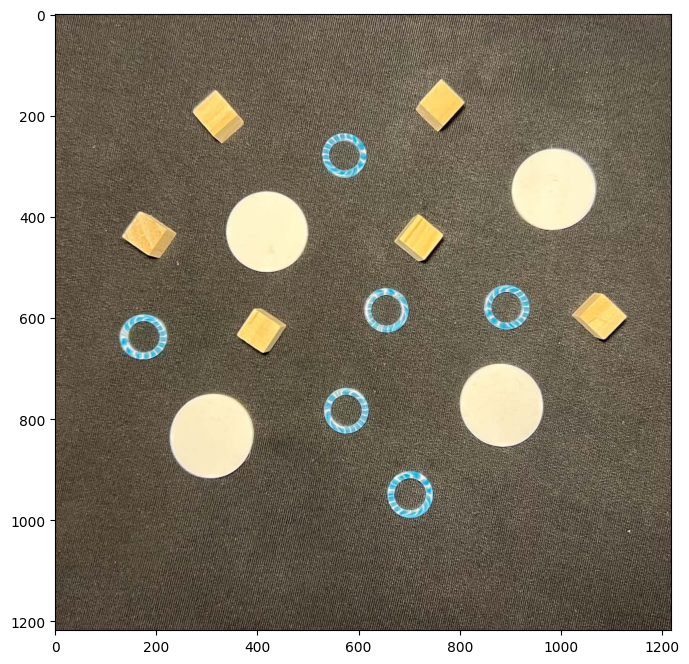

In [3]:
img = io.imread('czarne1.jpg')
plot(img, True)

## Preprocessing

#### RGB -> gray

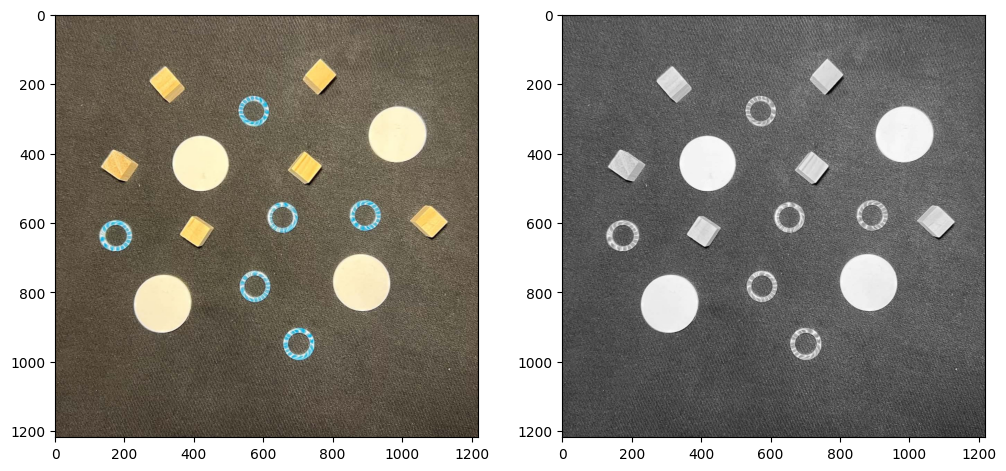

In [4]:
img_gray = color.rgb2gray(img)
plot_subplots(img, img_gray)

#### negative

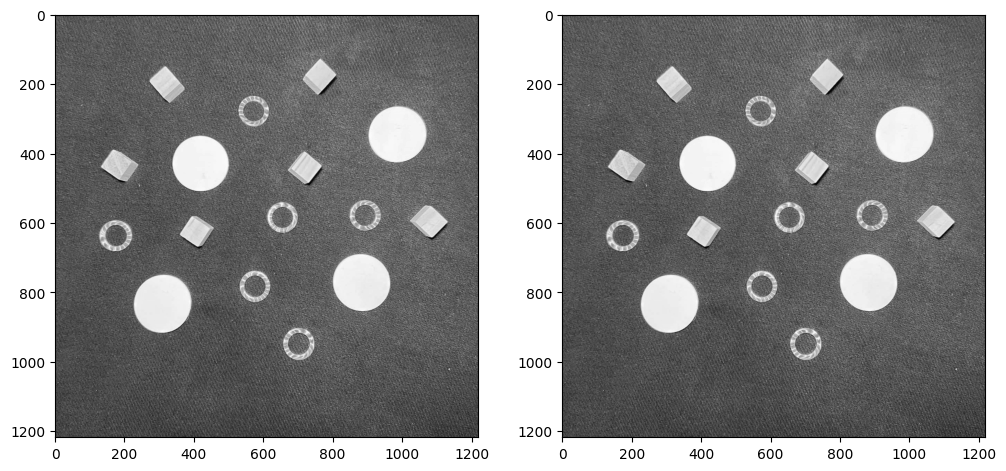

In [5]:
# img_negative = 1-img_gray
img_negative = img_gray
plot_subplots(img_gray, img_negative)

#### histogram equalization --- clahe

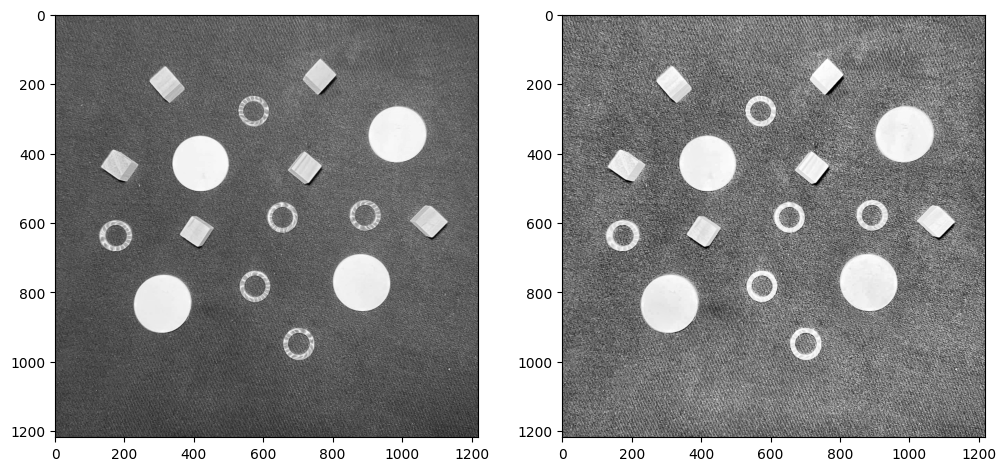

In [6]:
img_equalized = exposure.equalize_adapthist(img_negative)
img_equalized = (img_equalized*255).astype('uint8')
plot_subplots(img_negative, img_equalized)

#### mean filtering - wygładzanie

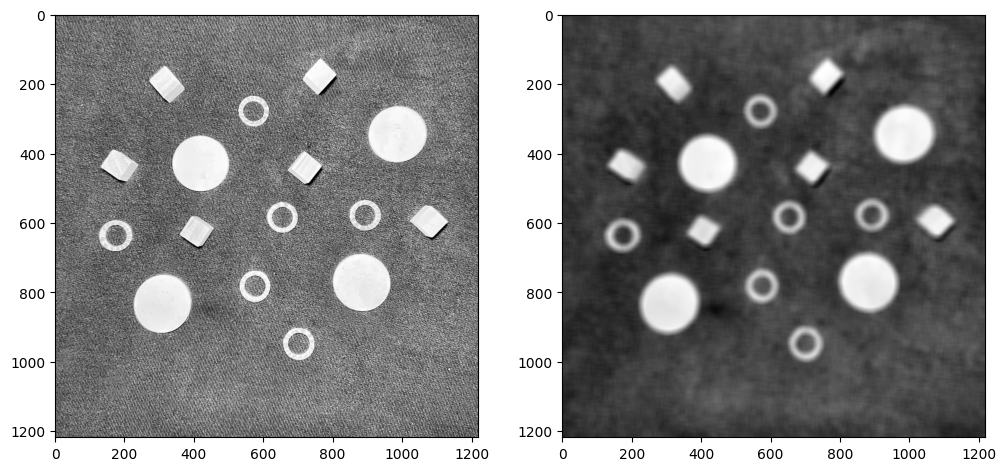

In [7]:
img_filtered = filters.rank.mean(img_equalized, np.ones([21,21]))
plot_subplots(img_equalized, img_filtered)

#### thresholding and binarization

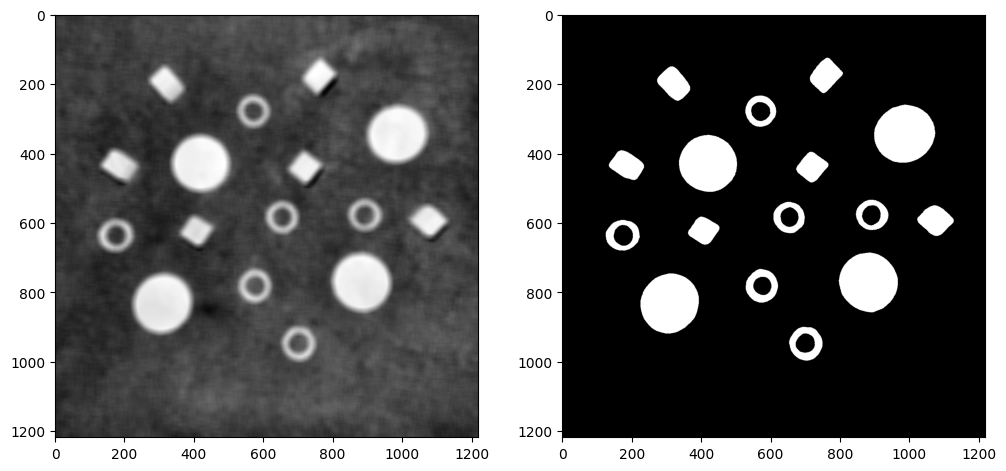

In [8]:
threshold = filters.threshold_otsu(img_filtered)
# threshold = 130
img_bin = img_filtered > threshold
plot_subplots(img_filtered, img_bin)

#### clear borders

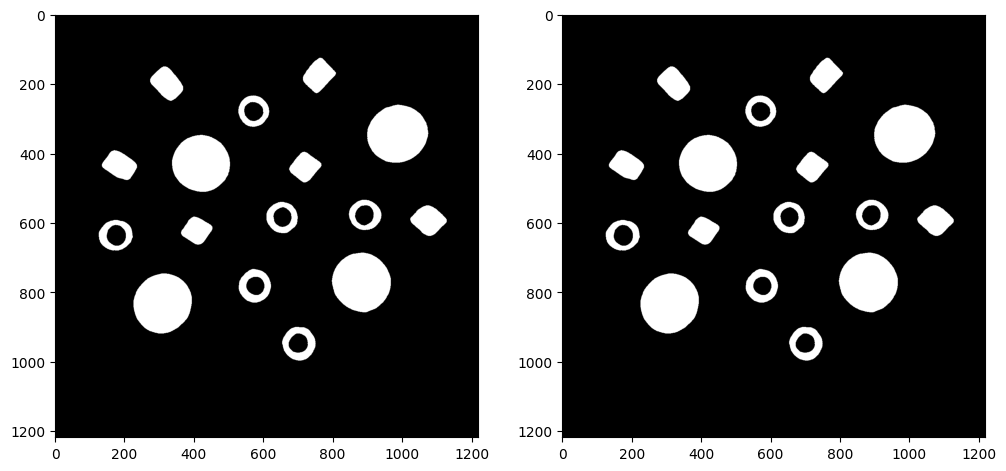

In [9]:
img_cleared_borders = segmentation.clear_border(img_bin)
plot_subplots(img_bin, img_cleared_borders)

####  remove noise - binary opening

C:\Users\wikik\AppData\Local\Temp\ipykernel_17900\3872520814.py:3: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  img_opened = morphology.binary_opening(img_cleared_borders, np.ones([k,k]))


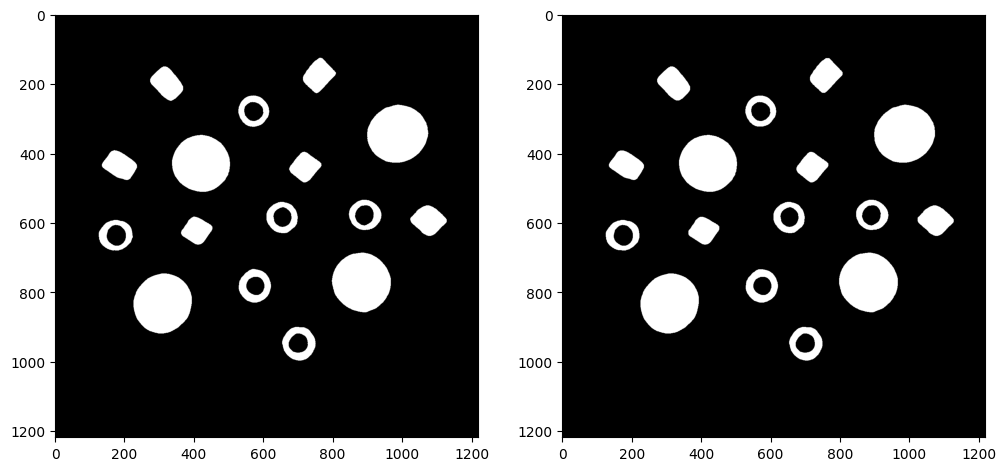

In [10]:
# img_opened = morphology.binary_opening(img_cleared_borders, np.ones([31,31]))
k = 7
img_opened = morphology.binary_opening(img_cleared_borders, np.ones([k,k]))
plot_subplots(img_cleared_borders, img_opened)

####  fill holes - binary closing

C:\Users\wikik\AppData\Local\Temp\ipykernel_17900\3074839471.py:1: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  img_preprocessed = morphology.binary_closing(img_opened, np.ones([7,7]))


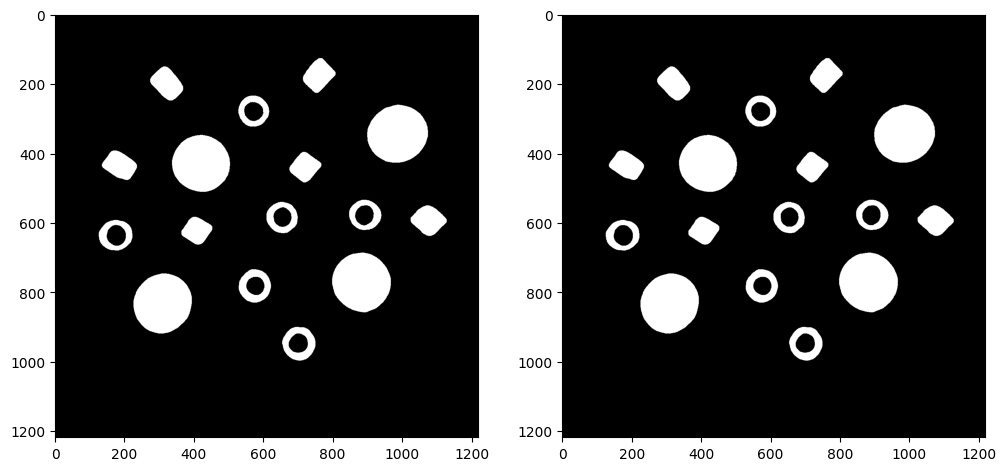

In [11]:
img_preprocessed = morphology.binary_closing(img_opened, np.ones([7,7]))
plot_subplots(img_opened, img_preprocessed)

## Feature extraction

In [12]:
def calc_rectangularity(area, bbox_area):
    return area/bbox_area


def calc_roundness(area, perimeter):
    return (4*np.pi*area)/perimeter**2


def calc_elongation(bbox_width, bbox_length):
    return 1 - bbox_width/bbox_length

### Find objects - connected-components labeling

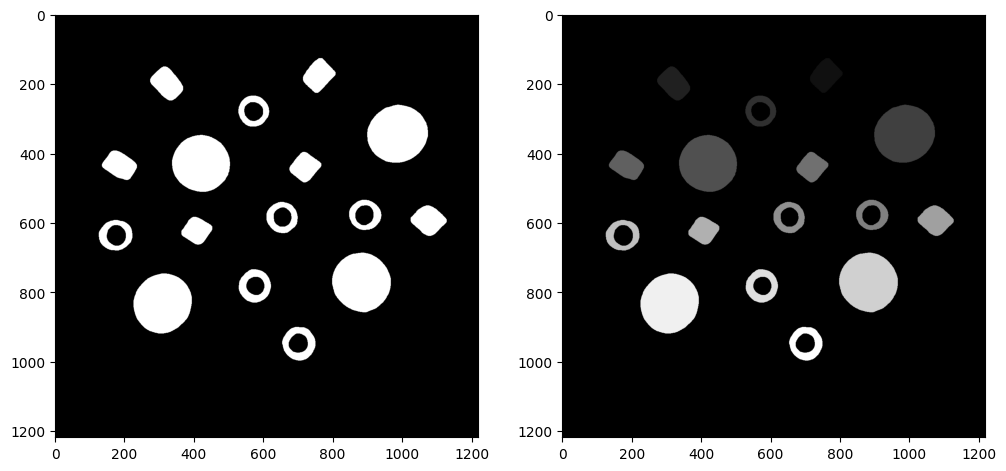

In [13]:
img_labeled = measure.label(img_preprocessed, connectivity=2)
plot_subplots(img_preprocessed, img_labeled)

### Use regionprops to find some of the object properties/features

In [14]:
regionprops = measure.regionprops(img_labeled)

### Get object labels (exclude 0 - background)

In [15]:
labels = np.unique(img_labeled)[1:]
print(labels)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]


### Extract features and construct the features vector for each object
Features:

- roundness
- rectangularity
- elongation
- R channel of RGB color
- G channel of RGB color

In [16]:
feature_vectors = []
for label, rp in zip(labels, regionprops):
    # get object of specific label
    obj = img_labeled == label
    # roundness
    roundness = calc_roundness(rp.area, rp.perimeter)
    # rectangularity
    rectangularity = calc_rectangularity(rp.area, rp.bbox_area)
    # elongation
    # elongation = calc_elongation(rp.bbox[3] - rp.bbox[2], rp.bbox[1] - rp.bbox[0])
    # corrected?
    elongation = calc_elongation(rp.bbox[3] - rp.bbox[1], rp.bbox[2] - rp.bbox[0])
    # R color channel
    red_color = img[:,:,0][obj].mean()
    # G color channel
    green_color = img[:,:,1][obj].mean()
    area = rp.area
    # construct feature vector
    feature_vector = [roundness, rectangularity, elongation, red_color, green_color, area]

    # add feature vector to the list containing feature vectors of the other objects
    feature_vectors.append(feature_vector)
    # print(rp.bbox)

C:\Users\wikik\AppData\Local\Temp\ipykernel_17900\4192948119.py:8: FutureWarning: `RegionProperties.bbox_area` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.area_bbox` instead. 
  rectangularity = calc_rectangularity(rp.area, rp.bbox_area)


## Object classification - K-means clustering

### Convert list of features vectors to numpy array

In [17]:
feature_vectors = np.array(feature_vectors)
feature_vectors = StandardScaler().fit_transform(feature_vectors)

### K-means clustering

#### Calculate centorids

In [18]:
# initial_k = np.stack([feature_vectors[10], feature_vectors[12], feature_vectors[14]])
initial_k = 3
centroids, _ = kmeans(feature_vectors, k_or_guess=initial_k, iter=20000, thresh=0.01)
print(centroids)

[[ 0.88993378  1.43043102  0.43193191  0.86670411  1.50865339  1.72467528]
 [ 0.69288158  0.15134889 -0.493163    0.70477376 -0.01261031 -0.49443696]
 [-1.28617076 -1.10496957  0.2052084  -1.2825765  -0.99315862 -0.65534656]]


#### Assign class to each observation

In [19]:
classes, _ = vq(feature_vectors, centroids)
print(classes)

[1 1 2 0 0 1 1 2 2 1 1 2 0 2 0 2]


### Create mask for each class

In [20]:
masks = {}
for c in np.unique(classes):
    mask = np.zeros(img_labeled.shape)
    # print(img_labeled.shape)
    for label in labels[classes == c]:
        mask += img_labeled == label
    masks = {**masks, c: mask.astype(bool)}

### Mark classified objects

In [21]:
def mark_objects(img, mask, colors):
    img_copy = img.copy()
    img_copy[mask, 0] = colors[0]
    img_copy[mask, 1] = colors[1]
    img_copy[mask, 2] = colors[2]
    plt.figure(figsize=(16,24))
    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.subplot(1,3,2)
    plt.imshow(mask, cmap=plt.cm.gray)
    plt.subplot(1,3,3)
    plt.imshow(img_copy)
    plt.show()

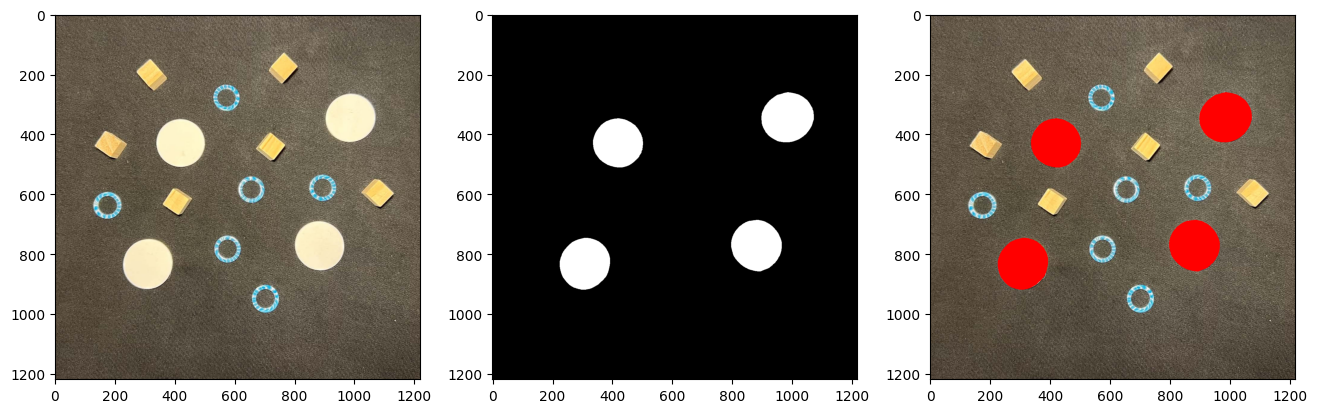

In [22]:
mark_objects(img, masks[0], (255,0,0))

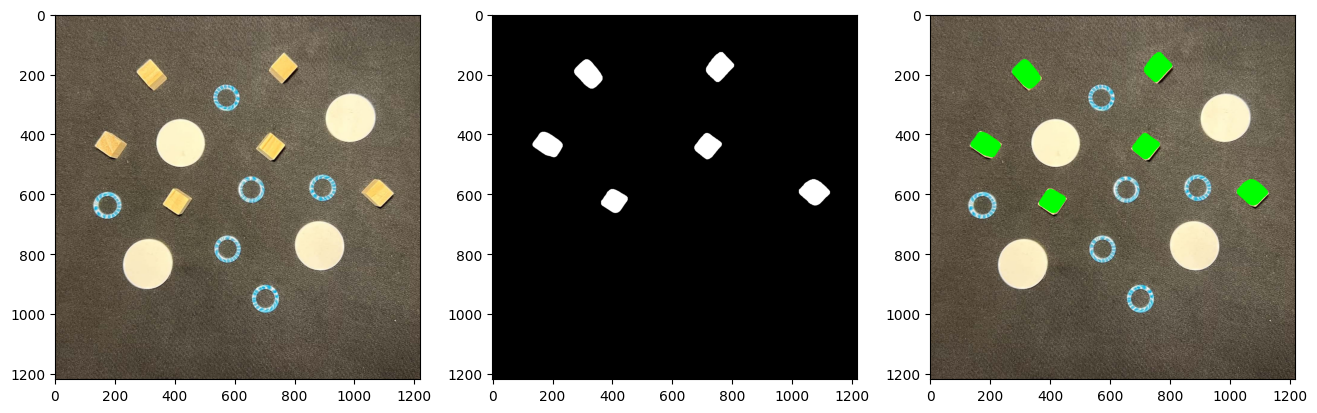

In [23]:
mark_objects(img, masks[1], (0,255,0))

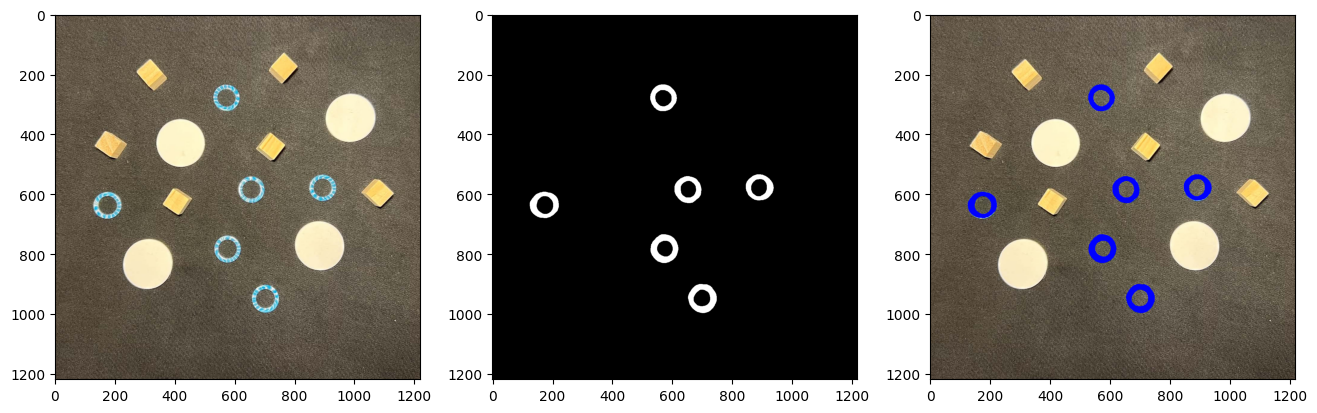

In [24]:
mark_objects(img, masks[2], (0,0,255))